# Laser Off Code

In [ ]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

# Set Laser and Powermeters Code

In [ ]:
params.laser_set_standard(laser, wavelength=1550e-9, power=7)
params.laser_get_standard(laser)
params.pmeter_set_standard(pmeter=pm100d, wavelength=1550e-9)
params.pmeter_set_standard(pmeter=pms120, wavelength=1550e-9)

# Import

In [1]:
import time
from time import sleep, monotonic
import datetime
import numpy as np
import matplotlib.pyplot as plt
import sys
import pyvisa
import qcodes as qc
from qcodes.dataset import Measurement
from qcodes.dataset import do0d
from qcodes.dataset.experiment_container import new_experiment, load_experiment_by_name
from qcodes.dataset.plotting import plot_by_id
from qcodes.dataset.data_set import load_by_id, load_by_counter
from qcodes import initialise_or_create_database_at, new_data_set, new_experiment
from qcodes.station import Station
initialise_or_create_database_at("./2026-05-11_SNSPD11.db")
from functions import osc_set_standard, osc_check_standard, capture_trace, capture_trace_simple
from functions import snspd_dark_counts
from functions import snspd_counts_vs_wavelength
from functions import laser_set_standard, laser_get_standard
from functions import snspd_counts_vs_current
import snspd
params = snspd.snspd('snspd11.yaml')

# Set up experiment
exp_name = 'SNSPD11_11_05_2026'
sample_name = '00'

try:
    exp = qc.load_experiment_by_name(exp_name, sample=sample_name)
    print('Experiment loaded. Last ID no:', exp.last_counter)
except ValueError:
    exp = new_experiment(exp_name, sample_name)
    print('Started new experiment')

Logging hadn't been started.
Activating auto-logging. Current session state plus future input saved.
Filename       : C:\Users\QNL\.qcodes\logs\command_history.log
Mode           : append
Output logging : True
Raw input log  : False
Timestamping   : True
State          : active
Qcodes Logfile : C:\Users\QNL\.qcodes\logs\260512-29744-qcodes.log
Experiment loaded. Last ID no: 67


In [122]:
import importlib
importlib.reload(snspd)
params = snspd.snspd('snspd11.yaml')

# Instruments

In [2]:
station = Station(config_file="friesland.yaml")
dmm = station.load_instrument("dmm", revive_instance=True)
yoko = station.load_instrument("yoko", revive_instance=True)
laser = station.load_instrument("laser", revive_instance=True)
MS = station.load_instrument("mso5", revive_instance=True)
# pm100usb = station.load_instrument("pm100usb", revive_instance=True)
pm100d = station.load_instrument("pm100d", revive_instance=True) 
pms120 = station.load_instrument("pms120", revive_instance=True)
tc = station.load_instrument("fridge", revive_instance=True)
p_att = station.load_instrument("dmm_keithley", revive_instance=True) # excluding from snapshot because none of the parameters work anyway

2026-05-12 17:02:59,804 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ D:\SNSPD\SNSPD2\PPCL550.py:4: QCoDeSDeprecationWarning: The `qcodes.utils.helpers` module is deprecated. Please consult the api documentation at https://microsoft.github.io/Qcodes/api/index.html for alternatives.
  from qcodes.utils.helpers import create_on_off_val_mapping

2026-05-12 17:02:59,820 ¦ qcodes.instrument.instrument_base.com.visa ¦ ERROR ¦ visa ¦ _connect_and_handle_error ¦ 222 ¦ [laser(PPCL550)] Could not connect at ASRL13
Traceback (most recent call last):
  File "C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\qcodes\instrument\visa.py", line 218, in _connect_and_handle_error
    visa_handle, visabackend, resource_manager = self._open_resource(
                                                 ~~~~~~~~~~~~~~~~~~~^
        address, visalib
        ^^^^^^^^^^^^^^^^
    )
    ^
  File "C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\qcodes\instrument\visa.py", line 246, in _open_resou

Connected to: Agilent Technologies 34410A (serial:MY47027892, firmware:2.35-2.35-0.09-46-09) in 0.11s
Connected to: YOKOGAWA GS210 (serial:91T928105, firmware:2.02) in 0.03s


VisaIOError: VI_ERROR_RSRC_BUSY (-1073807246): The resource is valid, but VISA cannot currently access it.

# Calibration

In [5]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: False


In [10]:
params.laser_set_standard(laser, wavelength=1550e-9, power=7)
params.laser_get_standard(laser)
params.pmeter_set_standard(pmeter=pm100d, wavelength=1550e-9)
params.pmeter_set_standard(pmeter=pms120, wavelength=1550e-9)

time.sleep(2)

############################ TURN LASER ON ############################ 
laser.enable(True)
print(f'Laser enable status: {laser.enable()}')
time.sleep(10)

params.quick_check(pmeter10=pm100d, pmeter90=pms120, attenuator_name='beam splitter')


############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

2026-05-12 12:55:06,755 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py:702: UserWarning: read string doesn't end with termination characters
  return self.read()



Power: 7.0
Frequency coarse: 193.4144THz
Wavelength (calculated) is 1550.000713493928nm
Powermeter wavelength is 1.55e-06
Powermeter wavelength is 1.55e-06
Laser enable status: True
Starting experimental run with id: 10. 
10


2026-05-12 12:55:19,273 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py:702: UserWarning: read string doesn't end with termination characters
  return self.read()



Could not calculate attenuation, missing beam splitter values
power10: 0.000452246226, power90: 0.00487346621
Laser enable status: False


In [13]:
params.laser_set_standard(laser, wavelength=1550e-9, power=7)
params.laser_get_standard(laser)
params.pmeter_set_standard(pmeter=pm100d, wavelength=1550e-9)
params.pmeter_set_standard(pmeter=pms120, wavelength=1550e-9)

time.sleep(2)

############################ TURN LASER ON ############################ 
laser.enable(True)
print(f'Laser enable status: {laser.enable()}')
time.sleep(10)

params.quick_check(pmeter10=pm100d, pmeter90=pms120, attenuator_name='beam splitter')


############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

2026-05-12 12:57:35,835 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py:702: UserWarning: read string doesn't end with termination characters
  return self.read()



Power: 7.0
Frequency coarse: 193.4144THz
Wavelength (calculated) is 1550.000713493928nm
Powermeter wavelength is 1.55e-06
Powermeter wavelength is 1.55e-06
Laser enable status: True
Starting experimental run with id: 11. 
11


2026-05-12 12:57:48,330 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py:702: UserWarning: read string doesn't end with termination characters
  return self.read()



Could not calculate attenuation, missing beam splitter values
power10: 0.00045049598, power90: 0.00484418869
Laser enable status: False


In [14]:
data = load_by_id(11).get_parameter_data()

In [22]:
[load_by_id(ID).get_parameter_data()['power10']['power10'] for ID in range(9,12)]

[array([0.0004519]), array([0.00045225]), array([0.0004505])]

In [26]:
power10 = np.average(np.array([load_by_id(ID).get_parameter_data()['power10']['power10'] for ID in range(9,10)]))
power90 = np.average(np.array([load_by_id(ID).get_parameter_data()['power90']['power90'] for ID in range(9,10)]))

In [33]:
power90

np.float64(0.0048755575)

In [28]:
power10

np.float64(0.000451898552)

In [29]:
data = load_by_id(9).get_parameter_data()
bs10, bs90 = params.beam_splitter_calc(power10=power10, power90=power90)

In [30]:
bs10

np.float64(0.08482445422151369)

In [31]:
bs90

np.float64(0.9151755457784864)

Calibrate attenuators 

In [39]:
params.att_screw_name, params.att_blue_name

('VOA50PM', 'V1550PA')

In [42]:
params.bs10

0.08482445422151369

In [43]:
params.bs90

0.9151755457784864

Screw attenuator 

In [46]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: False


In [47]:
params.laser_set_standard(laser, wavelength=1550e-9, power=7)
params.laser_get_standard(laser)
params.pmeter_set_standard(pmeter=pm100d, wavelength=1550e-9)
params.pmeter_set_standard(pmeter=pms120, wavelength=1550e-9)

time.sleep(2)

############################ TURN LASER ON ############################ 
laser.enable(True)
print(f'Laser enable status: {laser.enable()}')
time.sleep(10)

params.quick_check(pmeter10=pm100d, pmeter90=pms120, attenuator_name=params.att_screw_name)

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

2026-05-12 13:25:53,287 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py:702: UserWarning: read string doesn't end with termination characters
  return self.read()



Power: 7.0
Frequency coarse: 193.4144THz
Wavelength (calculated) is 1550.000713493928nm
Powermeter wavelength is 1.55e-06
Powermeter wavelength is 1.55e-06
Laser enable status: True
Starting experimental run with id: 13. 
13


2026-05-12 13:26:05,815 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py:702: UserWarning: read string doesn't end with termination characters
  return self.read()



power10: 5.37282885e-09, power90: 0.00486719236, attenuation: 49.24092171282648
Laser enable status: False


In [53]:
params.laser_set_standard(laser, wavelength=1550e-9, power=7)
params.laser_get_standard(laser)
params.pmeter_set_standard(pmeter=pm100d, wavelength=1550e-9)
params.pmeter_set_standard(pmeter=pms120, wavelength=1550e-9)


############################ TURN LASER ON ############################ 
laser.enable(True)
print(f'Laser enable status: {laser.enable()}')
time.sleep(10)

params.calibrate(t=30, pmeter10=pm100d, pmeter90=pms120, attenuator_name=params.att_screw_name)

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

2026-05-12 13:35:09,691 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py:702: UserWarning: read string doesn't end with termination characters
  return self.read()



Power: 7.0
Frequency coarse: 193.4144THz
Wavelength (calculated) is 1550.000713493928nm
Powermeter wavelength is 1.55e-06
Powermeter wavelength is 1.55e-06
Laser enable status: True
Starting experimental run with id: 16. 
16


2026-05-12 13:35:20,397 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py:702: UserWarning: read string doesn't end with termination characters
  return self.read()



Finished in 43.9592457000399s
Laser enable status: False


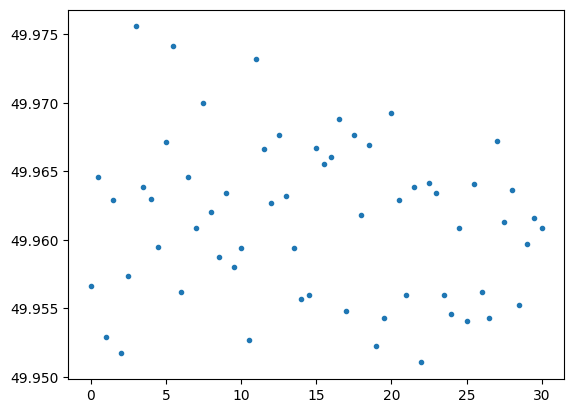

In [54]:
data = load_by_id(16).get_parameter_data()
attenuation = data['attenuation']['attenuation']
times = data['times']['times']
plt.plot(times, attenuation, '.')

Why did ID 13 quick check measure so low? 

In [55]:
params.laser_set_standard(laser, wavelength=1550e-9, power=7)
params.laser_get_standard(laser)
params.pmeter_set_standard(pmeter=pm100d, wavelength=1550e-9)
params.pmeter_set_standard(pmeter=pms120, wavelength=1550e-9)

time.sleep(2)

############################ TURN LASER ON ############################ 
laser.enable(True)
print(f'Laser enable status: {laser.enable()}')
time.sleep(10)

params.quick_check(pmeter10=pm100d, pmeter90=pms120, attenuator_name=params.att_screw_name)

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

2026-05-12 13:39:35,379 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py:702: UserWarning: read string doesn't end with termination characters
  return self.read()



Power: 7.0
Frequency coarse: 193.4144THz
Wavelength (calculated) is 1550.000713493928nm
Powermeter wavelength is 1.55e-06
Powermeter wavelength is 1.55e-06
Laser enable status: True
Starting experimental run with id: 17. 
17


2026-05-12 13:39:48,581 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py:702: UserWarning: read string doesn't end with termination characters
  return self.read()



power10: 4.54568871e-09, power90: 0.00486300979, attenuation: 49.96322119143912
Laser enable status: False


Repeating with fibre cleaned

In [58]:
params.laser_set_standard(laser, wavelength=1550e-9, power=7)
params.laser_get_standard(laser)
params.pmeter_set_standard(pmeter=pm100d, wavelength=1550e-9)
params.pmeter_set_standard(pmeter=pms120, wavelength=1550e-9)


############################ TURN LASER ON ############################ 
laser.enable(True)
print(f'Laser enable status: {laser.enable()}')
time.sleep(10)

params.calibrate(t=300, pmeter10=pm100d, pmeter90=pms120, attenuator_name=params.att_screw_name)

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

2026-05-12 13:45:45,580 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py:702: UserWarning: read string doesn't end with termination characters
  return self.read()



Power: 7.0
Frequency coarse: 193.4144THz
Wavelength (calculated) is 1550.000713493928nm
Powermeter wavelength is 1.55e-06
Powermeter wavelength is 1.55e-06
Laser enable status: True
Starting experimental run with id: 18. 
18


2026-05-12 13:45:56,144 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py:702: UserWarning: read string doesn't end with termination characters
  return self.read()



Finished in 432.9826130999718s
Laser enable status: False


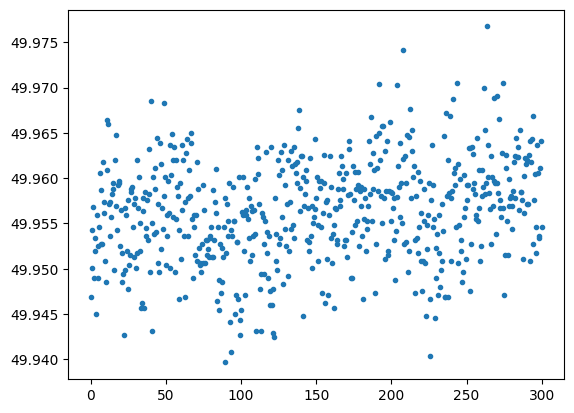

In [60]:
data = load_by_id(18).get_parameter_data()
attenuation = data['attenuation']['attenuation']
times = data['times']['times']
plt.plot(times, attenuation, '.')

Calibration blue attenuator 

In [63]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: False


In [62]:
params.att_blue_name

'V1550PA'

In [64]:
params.laser_set_standard(laser, wavelength=1550e-9, power=7)
params.laser_get_standard(laser)
params.pmeter_set_standard(pmeter=pm100d, wavelength=1550e-9)
params.pmeter_set_standard(pmeter=pms120, wavelength=1550e-9)

############################ TURN LASER ON ############################ 
laser.enable(True)
print(f'Laser enable status: {laser.enable()}')
time.sleep(10)

params.quick_check(pmeter10=pm100d, pmeter90=pms120, attenuator_name=params.att_blue_name)

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

2026-05-12 14:06:31,813 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py:702: UserWarning: read string doesn't end with termination characters
  return self.read()



Power: 7.0
Frequency coarse: 193.4144THz
Wavelength (calculated) is 1550.000713493928nm
Powermeter wavelength is 1.55e-06
Powermeter wavelength is 1.55e-06
Laser enable status: True
Starting experimental run with id: 19. 
19


2026-05-12 14:06:42,389 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py:702: UserWarning: read string doesn't end with termination characters
  return self.read()



power10: 6.05904837e-09, power90: 0.00487137493, attenuation: 48.722638042931585
Laser enable status: False


In [76]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: False


Check new function for electronic attenuator

In [77]:
params.laser_set_standard(laser, wavelength=1550e-9, power=7)
params.laser_get_standard(laser)
params.pmeter_set_standard(pmeter=pm100d, wavelength=1550e-9)
params.pmeter_set_standard(pmeter=pms120, wavelength=1550e-9)

############################ TURN LASER ON ############################ 
laser.enable(True)
print(f'Laser enable status: {laser.enable()}')
time.sleep(10)

v_attenuator = np.arange(3.4, 5.55, 0.05)


for v in v_attenuator: 
    p_att.write(f'VOLT {v}')
    time.sleep(5)

    params.calibrate_electronic(t=60, pmeter10=pm100d, pmeter90=pms120, attenuator_name=params.att_blue_name, p_att=p_att)


############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

2026-05-12 14:33:58,223 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py:702: UserWarning: read string doesn't end with termination characters
  return self.read()



Power: 7.0
Frequency coarse: 193.4144THz
Wavelength (calculated) is 1550.000713493928nm
Powermeter wavelength is 1.55e-06
Powermeter wavelength is 1.55e-06
Laser enable status: True
Starting experimental run with id: 22. 
22


2026-05-12 14:34:13,904 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py:702: UserWarning: read string doesn't end with termination characters
  return self.read()



Finished in 87.63393900007941s
Starting experimental run with id: 23. 
23


2026-05-12 14:35:47,111 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py:702: UserWarning: read string doesn't end with termination characters
  return self.read()



...

Finished in 87.54965920001268s
Starting experimental run with id: 48. 
48


2026-05-12 15:11:29,862 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py:702: UserWarning: read string doesn't end with termination characters
  return self.read()



Finished in 87.67332019994501s
Starting experimental run with id: 49. 
49


2026-05-12 15:13:03,169 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py:702: UserWarning: read string doesn't end with termination characters
  return self.read()

2026-05-12 15:13:10,232 ¦ qcodes.dataset.measurements ¦ WARNING ¦ measurements ¦ __exit__ ¦ 758 ¦ An exception occurred in measurement with guid: 876bd8c5-0000-0000-0000-019e1a9a5504;
Traceback:
Traceback (most recent call last):
  File "D:\SNSPD\SNSPD2\snspd.py", line 184, in calibrate_electronic
KeyboardInterrupt



KeyboardInterrupt: 

Keyboard interrupt - starting from where loop left off 

In [84]:
############################ TURN LASER ON ############################ 
laser.enable(True)
print(f'Laser enable status: {laser.enable()}')
time.sleep(10)

v_attenuator = np.arange(4.65, 5.55, 0.05)


for v in v_attenuator: 
    p_att.write(f'VOLT {v}')
    time.sleep(5)

    params.calibrate_electronic(t=60, pmeter10=pm100d, pmeter90=pms120, attenuator_name=params.att_blue_name, p_att=p_att)


############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: True
Starting experimental run with id: 50. 
50


2026-05-12 15:27:43,411 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py:702: UserWarning: read string doesn't end with termination characters
  return self.read()



Finished in 87.66337029996794s
Starting experimental run with id: 51. 
51


2026-05-12 15:29:16,733 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py:702: UserWarning: read string doesn't end with termination characters
  return self.read()



Finished in 87.65427860000636s
Starting experimental run with id: 52. 
52


...

Finished in 87.6316652999958s
Starting experimental run with id: 66. 
66


2026-05-12 15:52:34,522 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py:702: UserWarning: read string doesn't end with termination characters
  return self.read()



Finished in 87.58165720000397s
Starting experimental run with id: 67. 
67


2026-05-12 15:54:07,662 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py:702: UserWarning: read string doesn't end with termination characters
  return self.read()



Finished in 87.6954235000303s
Laser enable status: False


3.894396


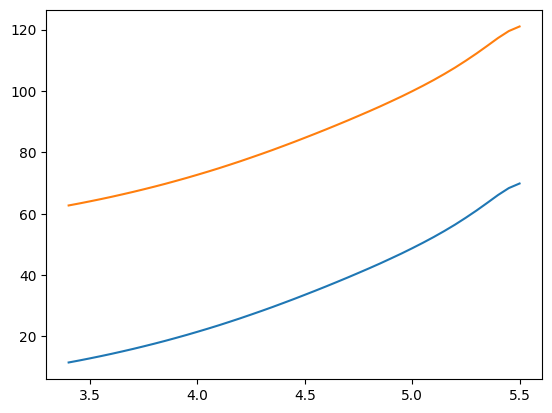

In [90]:
att_screw = params.avg_from_calibration(params.att_screw_calibration_id, 'attenuation')

ID_blue_calibration = list(np.arange(22, 39)) + [40] + list(np.arange(42, 49)) + list(np.arange(50, 68))

att_blue = [params.avg_from_calibration(ID, 'attenuation') for ID in ID_blue_calibration]
power_90_avg = np.average([params.avg_from_calibration(ID, 'power90') for ID in ID_blue_calibration])
v_attenuator_range = [params.avg_from_calibration(ID, 'v_attenuator') for ID in ID_blue_calibration]

db10 = "./2026-04-17_SNSPD10.db"
exname10 = 'SNSPD10'
sampname10 = '00'
ID = 7
attenuation_10 = params.load_id_from_database(db10, exname10, sampname10, ID).get_parameter_data()['attenuation']['attenuation']
still_temp_10 = params.load_id_from_database(db10, exname10, sampname10, ID).get_parameter_data()['still_temp']['still_temp']

fibre_attenuation = attenuation_10[-1]/2 # data taken cooling, last data point (coldest)
print(still_temp_10[-1])

total_attenuation = att_screw + att_blue + fibre_attenuation

plt.plot(v_attenuator_range, att_blue, label=f'Attenuation {params.att_blue_name}') 
plt.plot(v_attenuator_range, total_attenuation, label=f'Total (screw, blue, fridge fibre)') 
plt.legend()

In [113]:
fibre_attenuation

np.float64(1.20852380983398)

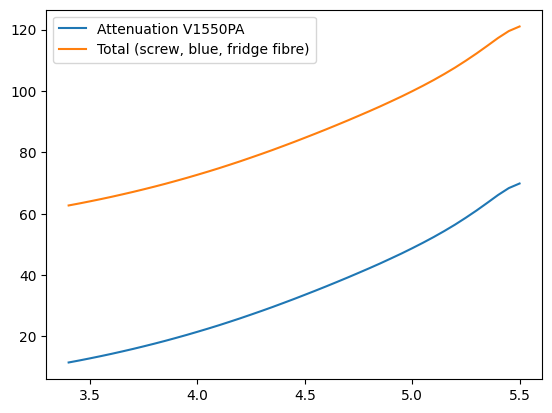

In [91]:
plt.plot(v_attenuator_range, att_blue, label=f'Attenuation {params.att_blue_name}') 
plt.plot(v_attenuator_range, total_attenuation, label=f'Total (screw, blue, fridge fibre)') 
plt.legend()

In [155]:
Nphotons = params.photon_number(power90=power_90_avg, total_attenuation=att_screw + att_blue + fibre_attenuation, wavelength=1550e-9)

In [100]:
total_attenuation

array([ 62.68338772,  63.34168812,  64.03682104,  64.75415806,
        65.50228788,  66.289608  ,  67.09824038,  67.94959968,
        68.82414812,  69.73424525,  70.68840902,  71.66627929,
        72.68756697,  73.73380326,  74.81453399,  75.9445344 ,
        77.09772809,  78.2990495 ,  79.51663235,  80.76760505,
        82.06538755,  83.37728977,  84.73360677,  86.10282831,
        87.49936303,  88.92996418,  90.38197319,  91.87367577,
        93.3820265 ,  94.93081873,  96.54427422,  98.18110348,
        99.90392297, 101.68577648, 103.55318404, 105.53031248,
       107.61888724, 109.86317465, 112.21874141, 114.71111279,
       117.25690084, 119.50805752, 121.00185154])

In [103]:
power_90_avg

np.float64(0.004875191359759753)

In [102]:
params.photon_number(power90=power_90_avg, total_attenuation=100, wavelength=1550e-9)

np.float64(352584.5679901821)

In [151]:
Nphotons = params.photon_number(power90=power_90_avg, total_attenuation=att_screw + att_blue + fibre_attenuation, wavelength=1550e-9)

In [ ]:
v_attenuator_range[-11]

In [130]:
Nphotons[-11], v_attenuator_range[-11]

(np.float64(360471.5578892342), np.float64(5.0))

In [153]:
total_attenuation=att_screw + att_blue + fibre_attenuation

In [154]:
total_attenuation[-11]

np.float64(99.90392296586974)

In [150]:
14e3*10

140000.0

In [147]:
light = 14e3*10
dark = 6*10
expected = 360471.5578892342

In [148]:
dark

60

In [149]:
(light-dark)/expected

0.38821370767621227

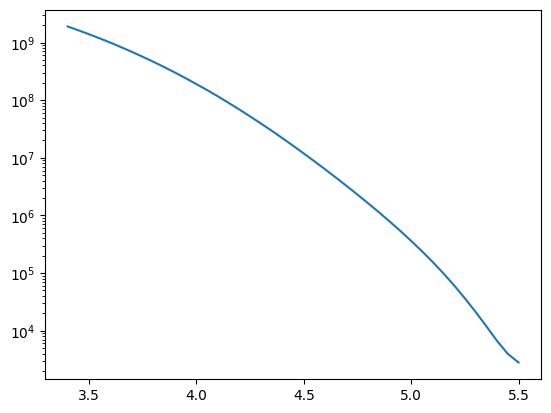

In [94]:
plt.semilogy(v_attenuator_range, Nphotons)

In [ ]:
plt.plot(v_attenuator_range, att_blue, label=f'Attenuation {params.att_blue_name}') 
plt.plot(v_attenuator_range, total_attenuation, label=f'Total (screw, blue, fridge fibre)') 
plt.legend()

fig, a

In [108]:
params.bs90

0.9151755457784864

In [127]:
import scipy.constants as spc 
total_attenuation = 100
wavelength = 1550e-9
Plaser =  power_90_avg/params.bs90
Pin = Plaser*params.bs10
Pdevice = Pin*(10**(-total_attenuation/10))
f = spc.c/wavelength 
Ephoton = spc.h*f
Nphotons = Pdevice/Ephoton

In [112]:
Nphotons

np.float64(35258.456799018204)

In [123]:
params.osc_set_standard_counts(MS)

In [134]:
############################ TURN LASER ON ############################ 
laser.enable(True)
print(f'Laser enable status: {laser.enable()}')
time.sleep(10)

Laser enable status: True


In [137]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: False


# Fibre Attenuation from Cooldown 10

In [ ]:
db10 = "./2026-04-17_SNSPD10.db"
exname10 = 'SNSPD10'
sampname10 = '00'
ID = 7
data_10 = params.load_id_from_database(db10, exname10, sampname10, ID).get_parameter_data()
power10_10 = data_10['power10']['power10']
power90_10 = data_10['power90']['power90']
attenuation_10 = data_10['attenuation']['attenuation']
still_temp_10 = data_10['still_temp']['still_temp']

fig, ax1 = plt.subplots()

ax2 = ax1.twinx()

ax1.semilogy(still_temp_10, power10_10, '.', color = 'tab:olive', label='Power \'Yellow Fibre (10)\'')
ax1.set_xlabel('Still Temperature (K)')
ax1.set_ylabel('Power Out (W)')
ax1.invert_xaxis()

ax2.semilogy(still_temp_10, attenuation_10, '--', color='tab:olive', label='Attenuation \'Yellow Fibre (10)\'') 
ax2.set_xlabel('Still Temperature (K)')
ax2.set_ylabel('Attenuation (dB)')

fig.legend()
